# 2 ~ Autoencoders: AE y DAE

La idea es entrenar un autoencoder (AE) solo con campañas "normales". El AE aprende a comprimir cada muestra a un espacio latente y reconstruirla — si solo ve patrones normales durante el entrenamiento, se especializa en reconstruir eso bien, y le va a costar reconstruir combinaciones de features que nunca vio (p. ej. una sequía).

El score de anomalía es directamente el error de reconstrucción: para cada muestra de test se calcula el error cuadrático entre la entrada y su reconstrucción, feature por feature, y se agrega (promedio) en un único número por muestra. La lógica es simple: a mayor error de reconstrucción, más anómala la muestra — el modelo "no supo" reconstruirla porque se aleja de lo que aprendió como normal.

El DAE (denoising AE) usa exactamente el mismo criterio de score (mismo error de reconstrucción sobre X_test limpio) — lo único que cambia es cómo se entrena: durante el entrenamiento se corrompe la entrada (ruido gaussiano o salt-and-pepper, ~10%) y se le pide al modelo que igual reconstruya la versión limpia. La intuición es que esto lo fuerza a aprender la estructura real de los datos normales en vez de memorizar detalles superficiales, haciendo la reconstrucción (y por lo tanto el score) más robusta.



In [61]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [62]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja  train: (6143, 72) | test anómalas: 251
maíz  train: (8082, 72) | test anómalas: 344


In [63]:
datasets = {
    "soja": ds,     # ya construido más arriba: build_crop_dataset(panel_z, "soja")
    "maiz": dsm,    # build_crop_dataset(panel_z, "maiz")
}
# Arquitectura: profundidad/ancho del encoder-decoder y tamaño del latente
arquitecturas = [
    {"hidden_dims": (64, 32), "latent_dim": 8},
    {"hidden_dims": (64, 32), "latent_dim": 16},
    {"hidden_dims": (32, 16), "latent_dim": 8},
    {"hidden_dims": (128, 64), "latent_dim": 16},
]
# Regularización: dropout y weight_decay (L2)
regularizacion = [
    {"dropout": 0.0, "weight_decay": 0.0},
    {"dropout": 0.1, "weight_decay": 0.0},
    {"dropout": 0.0, "weight_decay": 1e-4},
    {"dropout": 0.1, "weight_decay": 1e-4},
]

corrupcion_dae = [
    {"corruption": 0.1, "noise_type": "gaussian"},
    {"corruption": 0.2, "noise_type": "gaussian"},
    {"corruption": 0.1, "noise_type": "salt_pepper"},
]

## 2.1 ~ Autoencoder (AE)


In [64]:
resultados_ae = {}  # (cultivo, nombre) -> (mean, std)
for cultivo, dataset in datasets.items():
    for arq, reg in itertools.product(arquitecturas, regularizacion):
        nombre = f"AE_h{arq['hidden_dims']}_lat{arq['latent_dim']}_do{reg['dropout']}_wd{reg['weight_decay']}"
        def make_detector(seed, arq=arq, reg=reg):
            return AEDetector(
                hidden_dims=arq["hidden_dims"],
                latent_dim=arq["latent_dim"],
                dropout=reg["dropout"],
                weight_decay=reg["weight_decay"],
                random_state=seed,
            )
        mean, std = lab.evaluate(make_detector, dataset, lab.SEEDS, metric="pr_auc")
        resultados_ae[(cultivo, nombre)] = (mean, std)

In [65]:
ganador_ae = {}
params_ae = {}
for cultivo in datasets:
    keys_cultivo = [k for k in resultados_ae if k[0] == cultivo]
    mejor = max(keys_cultivo, key=lambda k: resultados_ae[k][0])
    ganador_ae[cultivo] = mejor
    # recuperamos los hiperparámetros ganadores (no solo el nombre) para reusarlos en el reentrenamiento
    for arq, reg in itertools.product(arquitecturas, regularizacion):
        nombre = f"AE_h{arq['hidden_dims']}_lat{arq['latent_dim']}_do{reg['dropout']}_wd{reg['weight_decay']}"
        if nombre == mejor[1]:
            params_ae[cultivo] = {**arq, **reg}
            break
    print(f"Ganador AE {cultivo}: {mejor[1]} -> PR-AUC {resultados_ae[mejor][0]:.3f} ± {resultados_ae[mejor][1]:.3f}  params={params_ae[cultivo]}")

Ganador AE soja: AE_h(128, 64)_lat16_do0.1_wd0.0001 -> PR-AUC 0.400 ± 0.041  params={'hidden_dims': (128, 64), 'latent_dim': 16, 'dropout': 0.1, 'weight_decay': 0.0001}
Ganador AE maiz: AE_h(128, 64)_lat16_do0.1_wd0.0 -> PR-AUC 0.399 ± 0.035  params={'hidden_dims': (128, 64), 'latent_dim': 16, 'dropout': 0.1, 'weight_decay': 0.0}


In [66]:
p_ds, p_dsm = params_ae["soja"], params_ae["maiz"]

filas_ae_ds, filas_ae_dsm = [], []
for seed in lab.SEEDS:
    ae_ds = AEDetector(hidden_dims=p_ds["hidden_dims"], latent_dim=p_ds["latent_dim"],
                        dropout=p_ds["dropout"], weight_decay=p_ds["weight_decay"],
                        max_epochs=300, patience=30, random_state=seed).fit(ds.X_train)          # entrena de verdad
    filas_ae_ds.append(lab.metrics(ae_ds.score_samples(ds.X_test), ds.y_test))                    # error de reconstrucción

    ae_dsm = AEDetector(hidden_dims=p_dsm["hidden_dims"], latent_dim=p_dsm["latent_dim"],
                         dropout=p_dsm["dropout"], weight_decay=p_dsm["weight_decay"],
                         max_epochs=300, patience=30, random_state=seed).fit(dsm.X_train)        # entrena de verdad
    filas_ae_dsm.append(lab.metrics(ae_dsm.score_samples(dsm.X_test), dsm.y_test))                 # error de reconstrucción

print("AE (soja, media±std entre semillas):")
display(lab.mean_std(filas_ae_ds))

print("\nAE (maíz, media±std entre semillas):")
display(lab.mean_std(filas_ae_dsm))

AE (soja, media±std entre semillas):


pr_auc              0.419±0.038
roc_auc             0.677±0.019
prec_at_k           0.437±0.022
recall_at_contam    0.182±0.024
dtype: str


AE (maíz, media±std entre semillas):


pr_auc              0.402±0.043
roc_auc             0.601±0.025
prec_at_k           0.390±0.028
recall_at_contam    0.176±0.030
dtype: str

La curva de loss del último AE (entrena bien; el problema no es el fit):

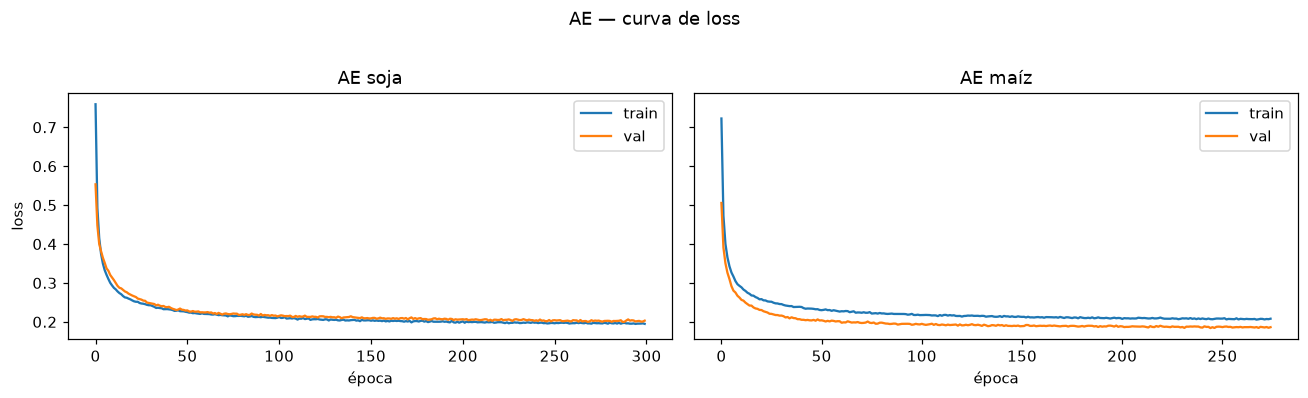

In [67]:
h_ds = pd.DataFrame(ae_ds.history_)
h_dsm = pd.DataFrame(ae_dsm.history_)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

ax[0].plot(h_ds["epoch"], h_ds["train_loss"], label="train")
ax[0].plot(h_ds["epoch"], h_ds["val_loss"], label="val")
ax[0].set_xlabel("época")
ax[0].set_ylabel("loss")
ax[0].set_title("AE soja")
ax[0].legend()

ax[1].plot(h_dsm["epoch"], h_dsm["train_loss"], label="train")
ax[1].plot(h_dsm["epoch"], h_dsm["val_loss"], label="val")
ax[1].set_xlabel("época")
ax[1].set_title("AE maíz")
ax[1].legend()

fig.suptitle("AE — curva de loss", y=1.02)
plt.tight_layout()
plt.show()

## 2.2 ~ Denoising AE (DAE)


In [ ]:
resultados_dae = {}
for cultivo, dataset in datasets.items():
    # usamos la arquitectura/regularización ganadora del AE para este cultivo (no un placeholder fijo)
    arq_ganadora = {"hidden_dims": params_ae[cultivo]["hidden_dims"], "latent_dim": params_ae[cultivo]["latent_dim"]}
    reg_ganadora = {"dropout": params_ae[cultivo]["dropout"], "weight_decay": params_ae[cultivo]["weight_decay"]}
    for corr in corrupcion_dae:
        nombre = f"DAE_{corr['noise_type']}_c{corr['corruption']}"
        def make_detector(seed, arq=arq_ganadora, reg=reg_ganadora, corr=corr):
            return DenoisingAEDetector(
                hidden_dims=arq["hidden_dims"],
                latent_dim=arq["latent_dim"],
                dropout=reg["dropout"],
                weight_decay=reg["weight_decay"],
                corruption=corr["corruption"],
                noise_type=corr["noise_type"],
                random_state=seed,
            )
        mean, std = lab.evaluate(make_detector, dataset, lab.SEEDS, metric="pr_auc")
        resultados_dae[(cultivo, nombre)] = (mean, std)


In [ ]:
filas = []
for (cultivo, nombre), (mean, std) in {**resultados_ae, **resultados_dae}.items():
    filas.append({"cultivo": cultivo, "modelo": nombre, "pr_auc_mean": mean, "pr_auc_std": std})
tabla = pd.DataFrame(filas).sort_values(["cultivo", "pr_auc_mean"], ascending=[True, False])
tabla

,cultivo,modelo,pr_auc_mean,pr_auc_std
31,maiz,"AE_h(128, 64)_lat16_do0.1_wd0.0001",0.418304,0.041287
29,maiz,"AE_h(128, 64)_lat16_do0.1_wd0.0",0.417147,0.031243
17,maiz,"AE_h(64, 32)_lat8_do0.1_wd0.0",0.391650,0.036573
25,maiz,"AE_h(32, 16)_lat8_do0.1_wd0.0",0.379119,0.040918
21,maiz,"AE_h(64, 32)_lat16_do0.1_wd0.0",0.375251,0.042734
23,maiz,"AE_h(64, 32)_lat16_do0.1_wd0.0001",0.373010,0.033684
19,maiz,"AE_h(64, 32)_lat8_do0.1_wd0.0001",0.368300,0.034259
36,maiz,DAE_gaussian_c0.2,0.364613,0.048780
16,maiz,"AE_h(64, 32)_lat8_do0.0_wd0.0",0.363501,0.048752
24,maiz,"AE_h(32, 16)_lat8_do0.0_wd0.0",0.361455,0.060438


In [ ]:
ganador_dae = {}
params_dae = {}
for cultivo in datasets:
    keys_cultivo = [k for k in resultados_dae if k[0] == cultivo]
    mejor = max(keys_cultivo, key=lambda k: resultados_dae[k][0])
    ganador_dae[cultivo] = mejor
    for corr in corrupcion_dae:
        nombre = f"DAE_{corr['noise_type']}_c{corr['corruption']}"
        if nombre == mejor[1]:
            params_dae[cultivo] = {**params_ae[cultivo], **corr}
            break
    print(f"Ganador DAE {cultivo}: {mejor[1]} -> PR-AUC {resultados_dae[mejor][0]:.3f} ± {resultados_dae[mejor][1]:.3f}  params={params_dae[cultivo]}")

In [ ]:
p_dae_ds, p_dae_dsm = params_dae["soja"], params_dae["maiz"]

filas_dae_ds, filas_dae_dsm = [], []
for seed in lab.SEEDS:
    dae_ds = DenoisingAEDetector(hidden_dims=p_dae_ds["hidden_dims"], latent_dim=p_dae_ds["latent_dim"],
                                  dropout=p_dae_ds["dropout"], weight_decay=p_dae_ds["weight_decay"],
                                  corruption=p_dae_ds["corruption"], noise_type=p_dae_ds["noise_type"],
                                  max_epochs=300, patience=30, random_state=seed).fit(ds.X_train)
    filas_dae_ds.append(lab.metrics(dae_ds.score_samples(ds.X_test), ds.y_test))

    dae_dsm = DenoisingAEDetector(hidden_dims=p_dae_dsm["hidden_dims"], latent_dim=p_dae_dsm["latent_dim"],
                                   dropout=p_dae_dsm["dropout"], weight_decay=p_dae_dsm["weight_decay"],
                                   corruption=p_dae_dsm["corruption"], noise_type=p_dae_dsm["noise_type"],
                                   max_epochs=300, patience=30, random_state=seed).fit(dsm.X_train)
    filas_dae_dsm.append(lab.metrics(dae_dsm.score_samples(dsm.X_test), dsm.y_test))

print("DAE (soja, media±std):")
display(lab.mean_std(filas_dae_ds))

print("\nDAE (maíz, media±std):")
display(lab.mean_std(filas_dae_dsm))

### AE vs DAE vs TODOS los baselines
Contra el conjunto completo de baselines del nb 1 (estadísticos y de modelos), no solo el IForest:

In [ ]:
def comparar(dataset, filas_ae, filas_dae, nombre_cultivo):
    resumen = {
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                    random_state=s).fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)
                    for s in lab.SEEDS],
        "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                    .fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)],
        "AE": filas_ae, "DAE": filas_dae,
    }
    print(f"--- {nombre_cultivo} ---")
    lab.plot_leaderboard(lab.leaderboard(resumen)); plt.show()
    display(lab.tabla(resumen))

comparar(ds, filas_ae_ds, filas_dae_ds, "soja")
comparar(dsm, filas_ae_dsm, filas_dae_dsm, "maíz")

Ambos quedan por debajo del baseline: el **error de reconstrucción con MSE no alcanza**.
El problema no es la arquitectura (se probaron 24 variantes en la exploración, todas
en un rango estrecho) sino el *score* — lo resolvemos con el VAE en el nb 3.

## 2.3 ~ IForest y OCSVM sobre el latente del AE
Idea de la literatura: usar el AE solo para **comprimir** y correr un detector  en
el espacio latente (16 dim), donde el ruido de features redundantes ya se descartó.
Entrenamos un AE, sacamos el latente con `.encode()`, y corremos los detectores ahí:

In [ ]:
ae = AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=300, patience=30,
                random_state=42).fit(ds.X_train)
Ztr, Zte = ae.encode(ds.X_train), ae.encode(ds.X_test)   # espacio latente (16 dim)
print("latente:", Ztr.shape)
latente = {
    "IForest sobre latente": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                              random_state=s).fit(Ztr).score_samples(Zte), ds.y_test) for s in SEEDS[:3]],
    "OCSVM-RBF sobre latente": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                .fit(Ztr).score_samples(Zte), ds.y_test)],
}
lab.tabla(latente)

latente: (6143, 16)


,pr_auc,roc_auc
OCSVM-RBF sobre latente,0.397±0.000,0.610±0.000
IForest sobre latente,0.273±0.016,0.501±0.013


**No mejora sobre el baseline.** El bottleneck del AE (entrenado por MSE) destruye la
estructura que el detector necesita: comprimir a un latente optimizado para reconstruir no
preserva la señal de anomalía. 

**Conclusión:** AE/DAE con MSE no alcanzan, ni directo ni vía latente. **El problema es el
score, no la arquitectura** → nb 3.